Imports and General Setup

In [33]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import pathlib
import pickle
import copy
import torch
from os import listdir
from os.path import isfile, join
from scipy.stats import sem

# Interactive plots
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

# Project modules (pulls in numpy, pandas, mne, sklearn, pyriemann, etc.)
from src.preprocessing import *
from src.training import *
from src.evaluation import *
from src.group_analysis import *

# Define paths
current_path = pathlib.Path().absolute().parent
recording_path = current_path / 'Recordings'
figure_outputs_path = current_path / 'Figures'

# List available recordings
recording_files = [f for f in listdir(recording_path) if isfile(join(recording_path, f)) and '.xdf' in f]
subject_names = [r.split('_')[0] for r in recording_files]
print('Recording files:', recording_files)
print('Subject IDs:', subject_names)

if not figure_outputs_path.exists():
    print('Output folder does not exist:', figure_outputs_path)

# Electrode groups
Electorde_Groups = {
    'FP': ['Fp1', 'Fp2'],
    'AF': ['AF7', 'AF3', 'AFz', 'AF4', 'AF8'],
    'F':  ['F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8'],
    'FC': ['FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6'],
    'C':  ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6'],
    'CP': ['CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6'],
    'P':  ['P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8'],
    'PO': ['PO7', 'PO3', 'POz', 'PO4', 'PO8'],
    'O':  ['Oz', 'O2', 'O1', 'Iz']
}

# Group tracking
group_results = []

Recording files: ['DD_1.xdf', 'DD_2.xdf', 'DD_3.xdf', 'DD_Idle.xdf', 'Fudge_MI3_1.xdf', 'Fudge_MI3_2.xdf', 'Fudge_MI3_3.xdf', 'Fudge_MI3_4.xdf', 'GiladRSL1.xdf', 'GiladRSL2.xdf', 'Gilad_3rdArm_0804_1.xdf', 'Gilad_3rdArm_0804_2.xdf', 'Gilad_3rdArm_0804_4.xdf', 'Gilad_3rdArm_0804_5.xdf', 'Gilad_3_AO.xdf', 'Gilad_MI3_1.xdf', 'Gilad_MI3_2.xdf', 'Gilad_MI3_3.xdf', 'Gilad_MI3_4.xdf', 'Gi_Block_1.xdf', 'Gi_Block_3.xdf', 'Gi_Block_4.xdf', 'g_mi_1.xdf', 'g_mi_3.xdf', 'g_mi_4.xdf', 'JE_Idle.xdf', 'JE_MI1.xdf', 'JE_MI2.xdf', 'JE_MI3.xdf', 'JE_MI4.xdf', 'NC_MI1.xdf', 'NC_MI2.xdf', 'NC_MI3.xdf', 'NC_MI4.xdf', 'NH37_Block_1.xdf', 'NH37_Block_2.xdf', 'NH37_Block_3.xdf', 'NH_34_MI5.xdf', 'NH_34_MI6.xdf', 'NH_3_AO.xdf', 'NH_3_MI1.xdf', 'NH_3_MI2.xdf', 'NH_3_MI3.xdf', 'NH_3_MI4.xdf', 'NH_Block_3.xdf', 'NoamV_Idle.xdf', 'NoamV_MI1.xdf', 'NoamV_MI2.xdf', 'NoamV_MI3.xdf', 'NoamV_MI4.xdf', 'Noam_3rdArm_0104_1.xdf', 'Noam_3rdArm_0104_2.xdf', 'Noam_3rdArm_0104_3.xdf', 'Noam_3rdArm_0104_4.xdf', 'Or_MI_1.xdf', 

Define Subject Name

In [95]:
subject_name = 'GiladRSL' # Manually define subject name

Choose a parameter dictionary 

In [96]:
params_dict={}
params_dict['PerformCsd']=True
params_dict['PerformAvgRef']=False
Electorde_Group_Names='FC+C+CP+P'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes (subject_name) # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 6
params_dict['LowPass']=6
params_dict['HighPass']=30
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=0.2
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='csp+lda'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','LeftHand','RightHand','Rest']


In [4]:
params_dict={}
params_dict['PerformCsd']=False
params_dict['PerformAvgRef']=True
Electorde_Group_Names='FC+C+CP+P'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes (subject_name) # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 4
params_dict['LowPass']=6
params_dict['HighPass']=35
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=0.2
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='ts+FGDA'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','LeftHand','RightHand']


Load XDF files and convert to combined mne Raw instance

In [97]:
xdf_files = [f for f in recording_path.glob('*.xdf') if subject_name in  f.name] # fill in name to select subject files
#OriginalRaw = Load_and_concatenate_xdf(xdf_files)
xdf_files[:]

[WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/GiladRSL1.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/GiladRSL2.xdf')]

In [104]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[:]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    #raw_for_ICA = raw_EEG_Preprocessing(current_path,raw,params_dict)
    filtered_raw,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict, pick_channels=True)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None
epochs

Creating RawArray with float64 data, n_channels=67, n_times=319501
    Range : 0 ... 319500 =      0.000 ...   639.000 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 49.38, 50.62 Hz: -3.01, -3.01 dB

Fitted sphere r

Number of events,158
Events,ClosePalm: 24LeftHand: 23Rest: 88RightHand: 23
Time range,-5.000 – 6.000 s
Baseline,off


Balance the classes if required

In [105]:
balanced_epochs = balance_epochs_by_subsampling(epochs, class_to_subsample='Rest')
epochs = balanced_epochs

Pre-processing

In [106]:
events = epochs.events
event_dict = epochs.event_id
params_dict['events_trigger_dict'] = {key: event_dict[key] for key in event_dict.keys() if key in params_dict['desired_events']}
train_inds,validation_inds,return_dict = Split_training_validation (epochs,filter_bank_epochs, params_dict['events_trigger_dict'])
epochs_copy = epochs.copy()
returned_dict=crop_the_data(epochs_copy,train_inds,validation_inds,params_dict['classifier_window_s'],params_dict['classifier_window_e'],use_all_for_training=False) 
train_set_data_uncropped=returned_dict['train_set_data_uncropped']
epochs_cropped=returned_dict['epochs_cropped']
train_set_data=returned_dict['train_set_data']
train_set_labels=returned_dict['train_set_labels']

validation_set_labels=returned_dict['validation_set_labels']
validation_set_data_uncropped=returned_dict['validation_set_data_uncropped']
#define cv on the data: 
cv = StratifiedShuffleSplit(10, test_size=0.2, random_state=random.randrange(1,80))
cv_split = cv.split(epochs_cropped.get_data(),events[:,2])

#filter bank related:
if params_dict['pipeline_name']=='fbcsp+lda': 
    train_set_data_fb=[]
    train_set_data_uncropped_fb=[]
    validation_set_data_fb=[]
    validation_set_data_uncropped_fb=[]
    for filtered_data_band_epoch in preprocessing_dict['filter_bank_epochs']:
        returned_dict_temp=crop_the_data(filtered_data_band_epoch,train_inds,validation_inds, params_dict['classifier_window_s'],params_dict['classifier_window_e'])
        #extract the train set data: 
        train_set_data_uncropped_temp=returned_dict_temp['train_set_data_uncropped']
        train_set_data_temp=returned_dict_temp['train_set_data']
        train_set_data_fb.append(train_set_data_temp)
        train_set_data_uncropped_fb.append(train_set_data_uncropped_temp)
        #extract the validation set data: 
        validation_set_data_uncroped_temp=returned_dict_temp['validation_set_data_uncroped']
        validation_set_data_temp=returned_dict_temp['validation_set_data']
        validation_set_data_fb.append(validation_set_data_temp)
        validation_set_data_uncropped_fb.append(validation_set_data_uncroped_temp)
    #create a 4d matrix of train data:     
    train_set_data_4d_array= np.transpose(np.array(train_set_data_fb),(1,2,3,0))
    train_set_data_uncropped_4d_array=np.transpose(np.array(train_set_data_uncropped_fb),(1,2,3,0)) 
    train_set_data=train_set_data_4d_array
    train_set_data_uncropped=train_set_data_uncropped_4d_array
    #create a 4d matrix of validation data: 
    validation_set_data_4d_array= np.transpose(np.array(validation_set_data_fb),(1,2,3,0))
    validation_set_data_uncropped_4d_array=np.transpose(np.array(validation_set_data_uncropped_fb),(1,2,3,0)) 
    validation_set_data_uncropped=validation_set_data_uncropped_4d_array


augmented_x,augmented_y = augment_data(params_dict['augmentation_params'], train_set_data,train_set_labels,epochs.info['sfreq'])

triggers_label_dict={val:key for key,val in params_dict['events_trigger_dict'].items()} 
test_data_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in validation_set_labels])  
augmented_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in augmented_y])  

putting aside 20% of the data: trial numbers are:
 [80 59 11 82 88 12 10 21  3 48 90 44 33 86 24 91 49 79 29]

remaining 80% of the trials go into training for cv:
 [58 89 46 60 17 41 32 77 14 56 55 85  5 40 53 68  6 19 71 34 35 47 83 16
  9 73 28 75  1 54 69 22  7 66 25 31 36 27  0 23  4 20 13 76 39 63 43 92
  2 26 50 67 30 72 51 81 61 57 37 62  8 18 78 65 84 87 45 15 52 64 42 70
 38 74]



Cross-Validation Evaluation 

In [107]:
scores_windows, folds_confusion_matrices_per_window, w_times =run_windowed_classification_aug_cv(epochs, returned_dict['epochs_cropped'], cv_split,params_dict)


Computing rank from data with rank=None
    Using tolerance 0.013 (2.2e-16 eps * 26 dim * 2.2e+12  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.015 (2.2e-16 eps * 26 dim * 2.6e+12  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.018 (2.2e-16 eps * 26 dim * 3.2e+12  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.015 (2.2e-16 eps * 26 dim * 2.5e+12  max singular value)
    Estimated rank (mag): 

In [108]:
plot_accuracy_over_time(scores_windows, w_times, params_dict, axes_handle=None)
plot_average_confusion_fixed_cv(folds_confusion_matrices_per_window, w_times, t_start=2.0, t_end=5.0)

(array([[0.74153846, 0.10615385, 0.        , 0.15230769],
        [0.20294599, 0.65957447, 0.02618658, 0.11129296],
        [0.29059829, 0.05470085, 0.5982906 , 0.05641026],
        [0.16025641, 0.13141026, 0.        , 0.70833333]]),
 array(['ClosePalm', 'LeftHand', 'Rest', 'RightHand'], dtype='<U9'))

In [109]:
scores_windows_s1 = scores_windows
folds_cm_s1 = folds_confusion_matrices_per_window
w_times_s1 = w_times

Training

In [110]:
clf,csp,lda = classifier_training(augmented_x,augmented_y,params_dict, BinaryClassification = False)
trained_clf = clf

Computing rank from data with rank=None
    Using tolerance 0.013 (2.2e-16 eps * 26 dim * 2.2e+12  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.015 (2.2e-16 eps * 26 dim * 2.5e+12  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.018 (2.2e-16 eps * 26 dim * 3.2e+12  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.015 (2.2e-16 eps * 26 dim * 2.6e+12  max singular value)
    Estimated rank (mag): 

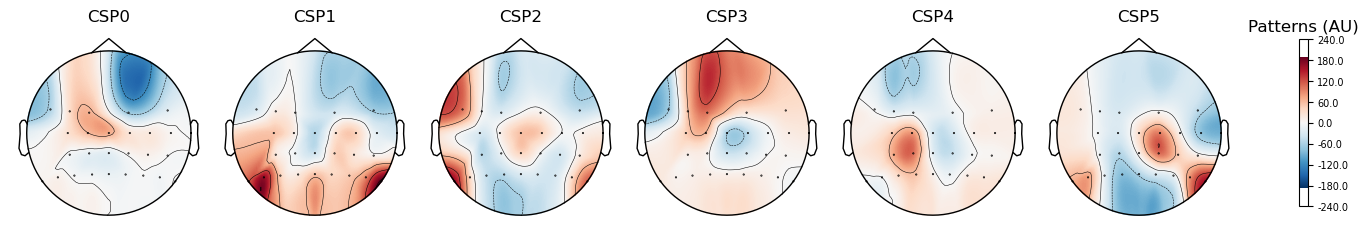

In [111]:
csp.plot_patterns(epochs.info, units='Patterns (AU)', size=1.5)

In [112]:
add_subject_to_group(group_results, subject_name, scores_windows_s1, folds_cm_s1, w_times_s1, 
                     params_dict=params_dict, save_dir=current_path / 'Metrics/Individuals' )

Added GiladRSL: 10 folds x 37 windows
  Saved metrics to c:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Metrics\Individuals\GiladRSL_CP_LH_RH_R_csp+lda.json


[{'subject_name': 'Tomer',
  'timestamp': '2026-02-19T17:17:52.881759',
  'scores_windows': [[0.08333333333333333,
    0.08333333333333333,
    0.125,
    0.10416666666666667,
    0.14583333333333334,
    0.20833333333333334,
    0.22916666666666666,
    0.3125,
    0.375,
    0.3958333333333333,
    0.375,
    0.3958333333333333,
    0.3958333333333333,
    0.375,
    0.2916666666666667,
    0.4166666666666667,
    0.4791666666666667,
    0.5416666666666666,
    0.5833333333333334,
    0.5833333333333334,
    0.6875,
    0.8125,
    0.8125,
    0.7916666666666666,
    0.7916666666666666,
    0.7708333333333334,
    0.7291666666666666,
    0.7083333333333334,
    0.6875,
    0.6666666666666666,
    0.6875,
    0.6666666666666666,
    0.5833333333333334,
    0.5833333333333334,
    0.5833333333333334,
    0.5208333333333334,
    0.3333333333333333],
   [0.125,
    0.10416666666666667,
    0.14583333333333334,
    0.125,
    0.125,
    0.14583333333333334,
    0.20833333333333334,
    0.

In [114]:

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'Metrics/Group')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes=4, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, w_times,t_start=2, t_end=5, normalize=True)

print("✓ Group analysis complete!")


Group results collected for 6 subjects:
  - Tomer: 10 folds
  - NC: 10 folds
  - NoamV: 10 folds
  - DD: 10 folds
  - JE: 10 folds
  - GiladRSL: 10 folds
Saved 6 subjects to c:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Metrics\Group\group_Tomer_NC_NoamV_DD_JE_GiladRSL_CP_LH_RH_R_csp+lda.json
✓ Group analysis complete!


In [106]:
import json

file_path = 'group_results_3_classes.json'

with open(file_path, 'r') as f:
    group_results = json.load(f)

print(f"Loaded data for {len(group_results)} subjects.")

Loaded data for 6 subjects.


In [414]:

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes = 3, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")

✓ Group analysis complete!


In [ ]:
len(folds_confusion_matrices_per_window[0])

49

Sanity check on unhandled recording: 

In [14]:
xdf_files = [f for f in recording_path.glob('*.xdf') if 'Tomer_' in  f.name] # fill in name to select subject files
#OriginalRaw = Load_and_concatenate_xdf(xdf_files)
xdf_files[-1:]


[WindowsPath('c:/Users/CensorLab/3rd_arm_MI/Recordings/Tomer_RSL2.xdf')]

In [383]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[-1:]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    _,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None

Creating RawArray with float64 data, n_channels=67, n_times=280755
    Range : 0 ... 280754 =      0.000 ...   561.508 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass fo

In [303]:
Raw_for_analysis = mne.preprocessing.compute_current_source_density(raw) ## Compute CSD
Raw_for_analysis = Raw_for_analysis.filter(8, 35, method='fir')
Raw_for_analysis.plot()


Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 0.0 mm
Origin device coordinates:    0.0 -0.0 0.0 mm
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 825 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  59 out of  59 | elapsed:    0.4s finished


In [76]:
original_ann = Raw_for_analysis.annotations
event_ann = expand_triggers_to_events(original_ann,Raw_for_analysis)

In [77]:
Raw_for_analysis.set_annotations(event_ann)

Raw_for_analysis.plot()

Channels marked as bad:
none


In [384]:
epochs

Number of events,46
Events,ClosePalm: 16LeftHand: 15RightHand: 15
Time range,-5.000 – 6.000 s
Baseline,off


In [385]:
trained_clf=clf
#data_to_predict=(data_set_fb_4d_array[inds,:])
data_to_predict=epochs[:].copy().crop(tmin=1,tmax=3
                                      ).get_data()
thresholded_prediction=trained_clf.decision_function(data_to_predict)
prediction=trained_clf.predict(data_to_predict)

#note that here you can decide on which thresholds to use to better optimize your "real" usecase
#thresholded_prediction
yhat=trained_clf.predict(data_to_predict)
lr_probs = trained_clf.predict_proba(data_to_predict)

In [386]:
# %%


# Function to get the list of event names for each epoch
# Function to compare actual event names with predicted event names and summarize mismatches
# Example usage:
# Assume `epochs` is your mne.Epochs object, and `predictions` is the model output

actual_events = get_epoch_events(epochs[:])  # Actual events from the epochs
predicted_events = np.array(prediction)  # Replace with your model predictions

# Compare actual events to predicted events
result = compare_events(actual_events, predicted_events)

# Output the comparison result
print(f"Accuracy: {result['accuracy']:.2f}")
if result['mismatch_details']:
    print("Mismatched epochs:")
    for mismatch in result['mismatch_details']:
        print(mismatch)
    
    print("\nMismatch Summary:")
    for mismatch_case, count in result['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches!")

Accuracy: 0.50
Mismatched epochs:
2 - RightHand (actual), ClosePalm (predicted)
5 - LeftHand (actual), RightHand (predicted)
7 - LeftHand (actual), ClosePalm (predicted)
8 - ClosePalm (actual), LeftHand (predicted)
12 - LeftHand (actual), RightHand (predicted)
15 - ClosePalm (actual), RightHand (predicted)
16 - ClosePalm (actual), LeftHand (predicted)
18 - LeftHand (actual), ClosePalm (predicted)
19 - LeftHand (actual), RightHand (predicted)
20 - LeftHand (actual), ClosePalm (predicted)
22 - RightHand (actual), LeftHand (predicted)
23 - RightHand (actual), ClosePalm (predicted)
26 - ClosePalm (actual), RightHand (predicted)
29 - LeftHand (actual), ClosePalm (predicted)
30 - LeftHand (actual), ClosePalm (predicted)
31 - ClosePalm (actual), RightHand (predicted)
32 - LeftHand (actual), ClosePalm (predicted)
36 - RightHand (actual), LeftHand (predicted)
39 - ClosePalm (actual), RightHand (predicted)
40 - RightHand (actual), LeftHand (predicted)
41 - LeftHand (actual), RightHand (predicted

In [387]:
# Function to compare events excluding Rest
# Example usage:
result_without_rest = compare_events_without_rest(actual_events, predicted_events)

# Output the comparison result
print(f"\n{'='*50}")
print(f"ACCURACY WITHOUT REST")
print(f"{'='*50}")
print(f"Accuracy (excluding Rest): {result_without_rest['accuracy']:.2f}")
print(f"Total non-Rest epochs evaluated: {result_without_rest['total_non_rest_epochs']}")

if result_without_rest['mismatch_details']:
    print("\nMismatched epochs (non-Rest only):")
    for mismatch in result_without_rest['mismatch_details'][:10]:  # Show first 10
        print(mismatch)
    if len(result_without_rest['mismatch_details']) > 10:
        print(f"... and {len(result_without_rest['mismatch_details']) - 10} more")
    
    print("\nMismatch Summary (non-Rest only):")
    for mismatch_case, count in result_without_rest['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches on non-Rest epochs!")


ACCURACY WITHOUT REST
Accuracy (excluding Rest): 0.50
Total non-Rest epochs evaluated: 46

Mismatched epochs (non-Rest only):
2 - RightHand (actual), ClosePalm (predicted)
5 - LeftHand (actual), RightHand (predicted)
7 - LeftHand (actual), ClosePalm (predicted)
8 - ClosePalm (actual), LeftHand (predicted)
12 - LeftHand (actual), RightHand (predicted)
15 - ClosePalm (actual), RightHand (predicted)
16 - ClosePalm (actual), LeftHand (predicted)
18 - LeftHand (actual), ClosePalm (predicted)
19 - LeftHand (actual), RightHand (predicted)
20 - LeftHand (actual), ClosePalm (predicted)
... and 13 more

Mismatch Summary (non-Rest only):
RightHand -> ClosePalm: 2 occurrence(s)
LeftHand -> RightHand: 4 occurrence(s)
LeftHand -> ClosePalm: 6 occurrence(s)
ClosePalm -> LeftHand: 3 occurrence(s)
ClosePalm -> RightHand: 5 occurrence(s)
RightHand -> LeftHand: 3 occurrence(s)


In [388]:
# Sanity check - windowed evaluation on trained classifier
scores_windows, confusion_matrices_per_window, w_times = sanity_check_trained_clf(
    trained_clf, epochs, params_dict
)

# Accuracy over time
plot_accuracy_over_time(scores_windows, w_times, params_dict)

# Average confusion matrix between time points

plot_average_confusion_fixed_cv(confusion_matrices_per_window, w_times, t_start=2, t_end=5)

(array([[0.40384615, 0.30288462, 0.29326923],
        [0.28717949, 0.41538462, 0.2974359 ],
        [0.25128205, 0.16923077, 0.57948718]]),
 array(['ClosePalm', 'LeftHand', 'RightHand'], dtype='<U9'))

In [21]:
# Pick the time window with best accuracy
best_idx = np.argmax(scores_windows[0])
cm, classes = confusion_matrices_per_window[0][best_idx]
plot_confusion_matrix(cm, classes, title=f"Confusion Matrix at t={w_times[best_idx]:.2f}s")

In [26]:
cm_avg, classes = plot_avg_confusion_matrix(
    confusion_matrices_per_window, w_times, 
    t_start=0, t_end=4.0
)

Save the trained model 


In [673]:
fname = 'DD_Raw_for_analysis_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Raw_for_analysis, picklefile)
#close the file
picklefile.close()

# === Saving ===
ann_fname = current_path / 'Models' / 'DD_ann_180226'
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)
# === Saving ===
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)



In [176]:
picks=params_dict['Electorde_Group']


import joblib
# === Saving ===
channels_fname = current_path / 'Models' / 'channels_list_180226.pkl'
model_fname = current_path / 'Models' / 'ts_model_180226.joblib'
with open(channels_fname, 'wb') as f:
    pickle.dump(picks, f)

joblib.dump(clf, model_fname)


# %%

Saved_Model = trained_clf
fname = 'DD_3rd_arm'+'Rest_ts_model_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Saved_Model, picklefile)
#close the file
picklefile.close()



picks=params_dict['Electorde_Group']
fname = 'electrode_picks-180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(picks, picklefile)
#close the file
picklefile.close()


fname = 'mean'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(mean_across_epochs, picklefile)
#close the file
picklefile.close()

params_dict
fname = 'params_dict-Rest_DD_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(params_dict, picklefile)
#close the file
picklefile.close()

In [ ]:

scaler = RobustScaler()
all_epoch_data_flat = all_epoch_data.reshape(all_epoch_data.shape[0], -1)
all_epoch_data_normalized = scaler.fit_transform(all_epoch_data_flat).reshape(all_epoch_data.shape)

# Update combined epochs with normalized data
epochs._data = all_epoch_data_normalized

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
